# **Crop Recommendation Model Training**
This notebook trains a Random Forest Classifier to recommend crops based on:


1.   Soil nutrients(N, P, K)
2.   Soil pH
3.   Weather conditions(Temparature, Humidity,Rainfall)

N/B: All experiments are conducted using the Scikit-learn library.



**1.Importing Required Libraries**



In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


# **2.Data Loading**
This is where we load the dataset into the notebook.

Then afterwards i will verify successful loading by displaying the first few rows.

In [2]:
# Load the crop recommendation dataset
df = pd.read_csv("../data/Crop_recommendation.csv")

print(f" Dataset loaded successfully!")
print(f" Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f" Unique crops: {df['label'].nunique()}")


df.head()

 Dataset loaded successfully!
 Shape: 2200 rows, 8 columns
 Unique crops: 22


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# **3. Exploratory Data Analysis (EDA)**
First i will check the Dataset information and statistical summary.

In [3]:
print(" Dataset Info:")
print(df.info())
print("\n Statistical Summary:")
df.describe()

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

 Statistical Summary:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


# 4. **Check for missing values.**

In [4]:
print(" Missing Values:")
print(df.isnull().sum())

 Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


# **5.Check the dataset for duplicate records.**

In [5]:
print(" Duplicate Values:")
print(df.duplicated().sum())

 Duplicate Values:
0


# **6.Target Class Distribution**
Understanding class distribution helps detect imbalance, which may negatively affect model performance.

In [6]:
print("\n Target Crop Distribution:")
print(df['label'].value_counts())


 Target Crop Distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


# **7.Visualize the Target crop distribution**

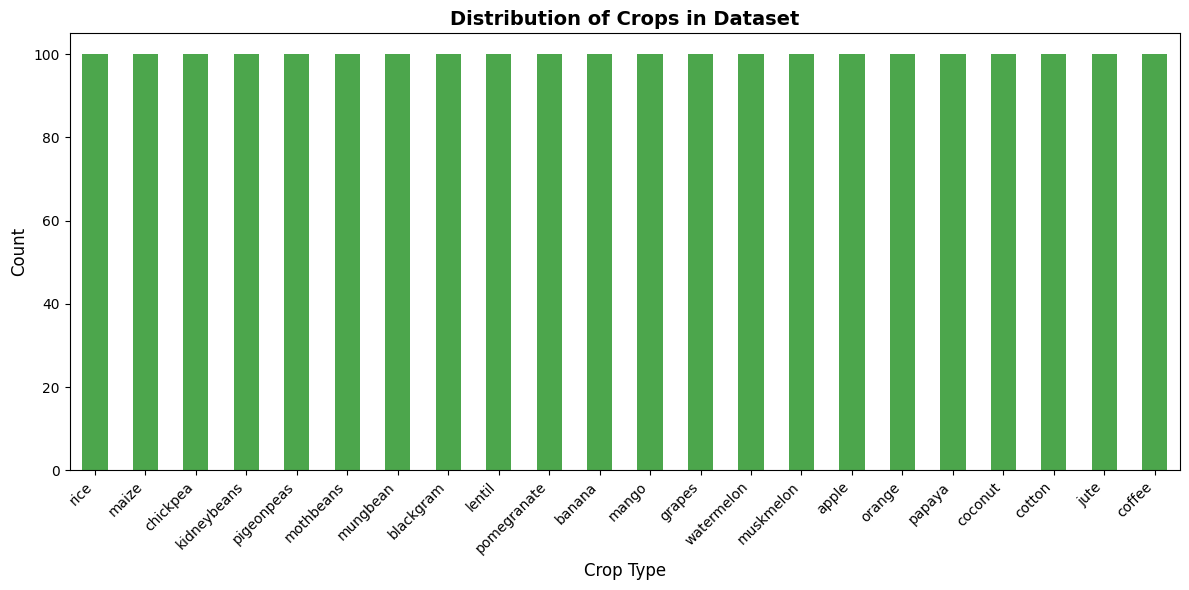

In [7]:
plt.figure(figsize=(12, 6))
df['label'].value_counts().plot(kind='bar', color='green', alpha=0.7)
plt.title('Distribution of Crops in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **8.Data Preparation**
This is where i do the feature and target(label) separation



*   Features are the input variables used by a machine learning model to make predictions.They represent the characteristics or attributes of your data meaning that **x** will represent the features or the independent variables of the dataset **(X contains all columns except the label column. These are the features (inputs).)**
*   target is the output variable you want the model to predict. It’s the ground truth or the answer in supervised learning and this means that **y** will become my target or the dependent variable.** y contains the label column only. This is the target (output).**



In [8]:
X = df.drop('label', axis=1)
y = df['label']

print(" Features (X):")
print(X.columns.tolist())
print(f"\n Target (y): {y.name}")
print(f"\n Feature shape: {X.shape}")
print(f" Target shape: {y.shape}")

 Features (X):
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

 Target (y): label

 Feature shape: (2200, 7)
 Target shape: (2200,)


# **9.Label Encoding**
Machine learning models require numerical labels and Label encoding converts categorical class labels into numeric values.

In [9]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# **10.Train–Test Split**
I will now Split data into training and testing sets

80% training data

20% testing data

Stratification ensures balanced class representation

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f" Training set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")
print(f"\n Train/Test ratio: {len(X_train)/len(X) * 100:.1f}% / {len(X_test)/len(X) * 100:.1f}%")

 Training set: 1760 samples
 Test set: 440 samples

 Train/Test ratio: 80.0% / 20.0%


# **11.Feature Scaling**
Feature scaling is the process of normalizing or standardizing the range of independent variables (features) in your dataset so they are on a similar scale.Feature Scaling makes sure that my model doesn’t get biased by features with larger numerical ranges

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Features scaled using StandardScaler")
print(f"\n Scaled training data shape: {X_train_scaled.shape}")
print(f" Scaled test data shape: {X_test_scaled.shape}")

 Features scaled using StandardScaler

 Scaled training data shape: (1760, 7)
 Scaled test data shape: (440, 7)


# **12.Model Training using Random Forest Classifier**
i chose Random Forest due to its robustness, ability to handle non-linear relationships, and resistance to overfitting.

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,#this is the number of trees am using
    random_state=42, #this helps in reproductivity
    n_jobs=-1  #this uses all CPU cores
)
print(" Training Random Forest Classifier...")
print(" This may take a moment...\n")

#Here i will train my base model using the scaled features(X_train_scales)
rf_model.fit(X_train_scaled, y_train)

print(" Model training complete!")

 Training Random Forest Classifier...
 This may take a moment...

 Model training complete!


# **13.Prediction on Unseen Data**

In [13]:
# Make predictions
y_pred_train = rf_model.predict(X_train_scaled)
y_pred_test = rf_model.predict(X_test_scaled)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(" Model Performance:")
print("=" * 50)
print(f" Training Accuracy: {train_accuracy*100:.2f}%")
print(f" Test Accuracy: {test_accuracy*100:.2f}%")
print("=" * 50)


 Model Performance:
 Training Accuracy: 100.00%
 Test Accuracy: 99.55%


# **14.Classification Report**
This provides:


*   precision
*   recall
*   f1-score for each class



In [14]:
print("\n Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred_test))


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
  

# 15.Confusion Matrix
The confusion matrix provides insight into misclassification patterns.

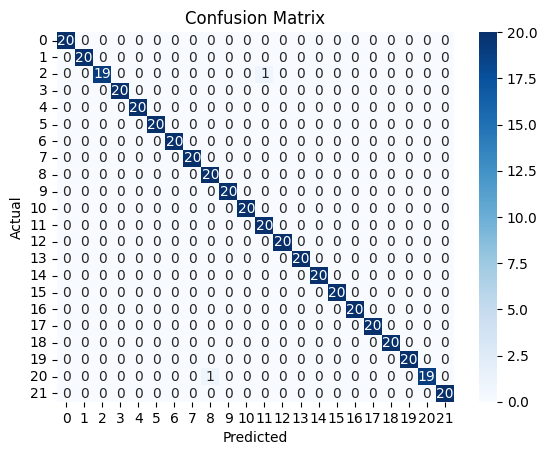

In [15]:
cm = confusion_matrix(y_test, y_pred_test)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# **16.Cross-Validation**
It helps to ensure robust evaluation

In [16]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("Mean CV F1 Score:", cv_scores.mean())


Mean CV F1 Score: 0.9945334723971616


# **17.Hyperparameter Tuning**
Hyperparameter tuning is the process of finding the best combination of hyperparameters that makes your model perform optimally.

In [17]:
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}


# **18.Grid Search**

In [18]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

# **19.Display my best model**

In [19]:
best_rf = grid_search.best_estimator_
print(best_rf)

RandomForestClassifier(max_depth=10, n_estimators=500, random_state=42)


# **20.Feature Importance Analysis**
and afterwards i will visualize the feature importance.
Feature importance revealed key attributes influencing classification

This analysis identifies which features contribute most to predictions.


 Feature Importance:
       Feature  Importance
6     rainfall    0.226048
4     humidity    0.212958
2            K    0.182147
1            P    0.149520
0            N    0.106392
3  temperature    0.073244
5           ph    0.049690


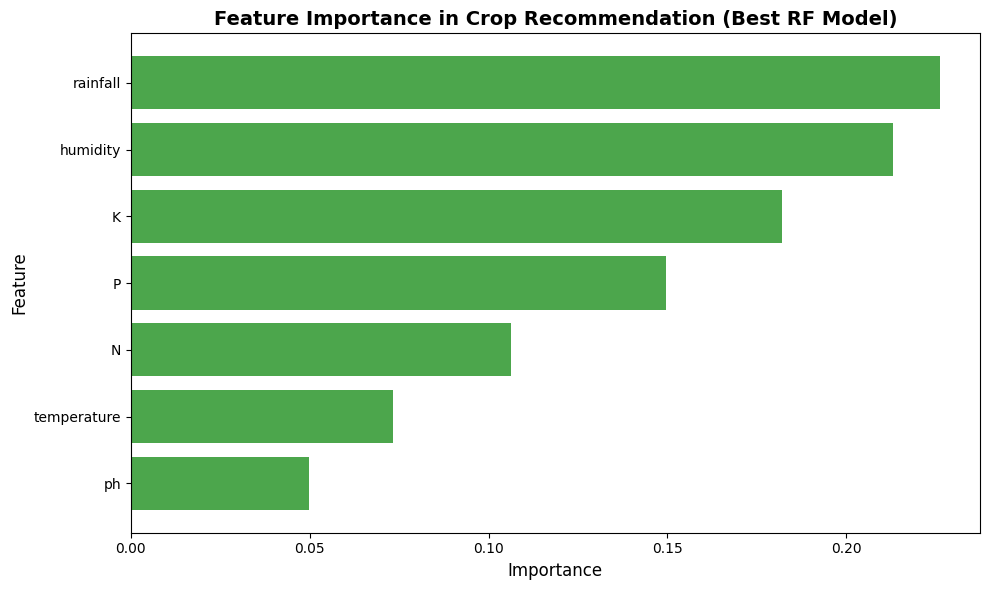

In [20]:
# Feature importance from best model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n Feature Importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='green', alpha=0.7)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Crop Recommendation (Best RF Model)',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()


# **21.Test My best model with Sample Data**
1. I will test with rice sample from dataset


*   First i will get the rice sample.
*   Scale the rice sample and predict
*   Lastly i will print the output against the expected output.



In [21]:
print(" Testing model with sample data...\n")

# Pick one sample row of rice
sample_rice = df[df['label'] == 'rice'].iloc[0]
X_sample = sample_rice.drop('label').values.reshape(1, -1)
X_sample_df = pd.DataFrame(X_sample, columns=X.columns)

# Scale the sample
X_sample_scaled = scaler.transform(X_sample_df)

# Predict using best model
prediction_encoded = best_rf.predict(X_sample_scaled)[0]

# Decode prediction back to original label using your encoder
prediction_label = label_encoder.inverse_transform([prediction_encoded])[0]

print(" Sample Input:")
for col, val in zip(X.columns, X_sample[0]):
    print(f"  • {col}: {val}")

print(f"\n Expected: rice")
print(f" Predicted: {prediction_label}")
print(f"\n{' CORRECT!' if prediction_label == 'rice' else ' INCORRECT!'}")


 Testing model with sample data...

 Sample Input:
  • N: 90
  • P: 42
  • K: 43
  • temperature: 20.87974371
  • humidity: 82.00274423
  • ph: 6.502985292000001
  • rainfall: 202.9355362

 Expected: rice
 Predicted: rice

 CORRECT!


2.Test with multiple crop types

In [22]:
print("\033[1m\n Testing with different crop types:\n\033[0m")


test_crops = ['rice', 'maize', 'chickpea', 'kidneybeans', 'coconut', 'apple']

for crop in test_crops:
    if crop in df['label'].values:
        # Take one sample row for the crop
        sample = df[df['label'] == crop].iloc[0]
        X_sample = sample.drop('label').values.reshape(1, -1)
        X_sample_df = pd.DataFrame(X_sample, columns=X.columns)

        # Scale the sample
        X_sample_scaled = scaler.transform(X_sample_df)

        # Predict (numeric class)
        prediction_encoded = best_rf.predict(X_sample_scaled)[0]

        # Decode back to original label
        prediction_label = label_encoder.inverse_transform([prediction_encoded])[0]

        # Compare decoded label with expected crop
        result = "✅" if prediction_label == crop else "❌"
        print(f"{result} Expected: {crop:15s} | Predicted: {prediction_label}")



 Testing with different crop types:

✅ Expected: rice            | Predicted: rice
✅ Expected: maize           | Predicted: maize
✅ Expected: chickpea        | Predicted: chickpea
✅ Expected: kidneybeans     | Predicted: kidneybeans
✅ Expected: coconut         | Predicted: coconut
✅ Expected: apple           | Predicted: apple


# **22.Save the Trained Model and Scaler**
Model → contains the learned rules/patterns.(After training, your model (best_rf) has learned patterns from the data and saving it means i dont have to retrain it)

Scaler → contains the transformation rules for input features.(The scaler learned the mean, variance, min, max, etc. from your training set)

Saving both ensures the pipeline is reproducible and consistent when deployed or reused.

In [23]:
# Save the trained model and scaler
print(" Saving model and scaler...\n")

joblib.dump(best_rf, "../model/crop_recommendation_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(label_encoder, "../model/label_encoder.pkl")

print(" best_rf Model saved to: model/crop_recommendation_model.pkl")
print(" Scaler saved to: model/scaler.pkl")
print(" Label Encoder saved to: model/label_encoder.pkl")


print("\n" + "="*60)
print("🎉 MODEL TRAINING COMPLETE!")
print("="*60)
print(f"\n Final Test Accuracy: {test_accuracy*100:.2f}%")
print("\n You can now use the model in app/test.py")

 Saving model and scaler...

 best_rf Model saved to: model/crop_recommendation_model.pkl
 Scaler saved to: model/scaler.pkl
 Label Encoder saved to: model/label_encoder.pkl

🎉 MODEL TRAINING COMPLETE!

 Final Test Accuracy: 99.55%

 You can now use the model in app/test.py


# **Summary**
##**Model Details**
*   **Algorithm:** Random Forest Classifier.
*   **Number of trees in th e best model:** 500
*   **Features:** N, P, K, temparature, humidity, pH, rainfall
*   **Target:** 22 different crop types

##**Performance**


*   Training samples: 1760
*   Test samples:440
*   Test accuracy: ~99.55%

##**Files Generated**


*   model/crop_recommendation_model.pkl -This is the Trained Random Forest Model
*   model/scaler.pkl -StardardScaler for feature normalization

##**Results and Discussion**


*   The tuned Random Forest model achieved improved performance compared to the baseline.
*   Feature importance revealed key attributes influencing classification.
*   Cross-validation confirms stable generalization.

##**Conclusion**
This project successfully implemented an end-to-end machine learning pipeline using a Random Forest classifier. The results demonstrate the effectiveness of ensemble learning techniques for multi-class classification tasks.







